### Imports

In [2]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{torch.__version__}.html

Looking in links: https://data.pyg.org/whl/torch-2.9.0+cu126.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=3857024 sha256=932e7f69e18ab8f702b34b7f5d186d674035e9f20a07e8e1de5025c68e258cfc
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
Successfully built torch-scatter
Looking in links: https://data.pyg.org/whl/torch-2.9.0+cu126.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 18.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: Operation cancelled by user
Looking in links: https://data.pyg.org/whl/torch-2.9.0+cu126.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/l

In [3]:
%%capture
!pip install torch_geometric

In [4]:
import torch
import pandas as pd
import numpy as np
import sklearn
import torch_geometric as pyg
import sklearn.preprocessing as skpreprocess

In [5]:
# !pip freeze > requirements.txt

### Set seeds for reproducibility

In [6]:
import os
import random

SEED = 42
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

### Dataset Preprocessing

Make sure `SNP_info.csv` is in the same directory before running the next step.

In [10]:
csv_path = 'https://github.com/vincent-angelo/crop-resistance-prediction/raw/main/SNP_info.csv'
df = pd.read_csv(csv_path, encoding='unicode_escape')
df = df[:-1]

truncated_df = df.iloc[:1, 2:]

y_df = truncated_df.T
y_df = y_df.reset_index()
y_df.columns = y_df.iloc[0]
y_df = y_df[1:]


In [11]:
X_df = df.iloc[1:]
X_df.reset_index(drop=True, inplace=True)
X_df.drop(X_df.columns[1:3], axis=1, inplace=True)
X_df.columns = np.arange(len(X_df.columns))
X_df.set_index(0, inplace=True)
X_df = X_df.T

def remove_non_ascii(text):
    return ''.join(char for char in text if ord(char) < 128)

feature_names = [remove_non_ascii(name) for name in X_df.columns]
assert (len(set(feature_names)) == len(feature_names))
X_df.columns = feature_names


/tmp/ipython-input-2541306060.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_df.drop(X_df.columns[1:3], axis=1, inplace=True)


In [12]:
# Categorical data
mapping_dict = {
    'AA': 0,
    'GG': 1,
    'CC': 2,
    'TT': 3,
    'NN': 4,
}
X_df = X_df.replace(mapping_dict)


/tmp/ipython-input-1629847069.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_df = X_df.replace(mapping_dict)


In [13]:
X = torch.tensor(X_df.values.astype(float), dtype=torch.float)
y = torch.tensor(y_df.values.astype(float), dtype=torch.float)
print(f"X shape: {X.shape} | y shape: {y.shape}")

X shape: torch.Size([1175, 127]) | y shape: torch.Size([1175, 2])


### Feature Engineering: Graphical Lasso

In [14]:
scaler = skpreprocess.StandardScaler()
X = torch.tensor(scaler.fit_transform(X).astype(float), dtype=torch.float)
graphical_lasso = sklearn.covariance.GraphicalLasso(alpha=0.3)
graphical_lasso.fit(X)

GraphicalLasso(alpha=0.3)

In [15]:
precision_matrix = graphical_lasso.precision_
precision_matrix

array([[ 1.00443317,  0.        ,  0.        , ..., -0.        ,
         0.        ,  0.        ],
       [ 0.        ,  1.00000001,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  1.00000005, ..., -0.        ,
        -0.        ,  0.        ],
       ...,
       [-0.        ,  0.        , -0.        , ...,  0.99999996,
        -0.        ,  0.        ],
       [ 0.        ,  0.        , -0.        , ..., -0.        ,
         1.00000002, -0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.        ,  0.99999993]])

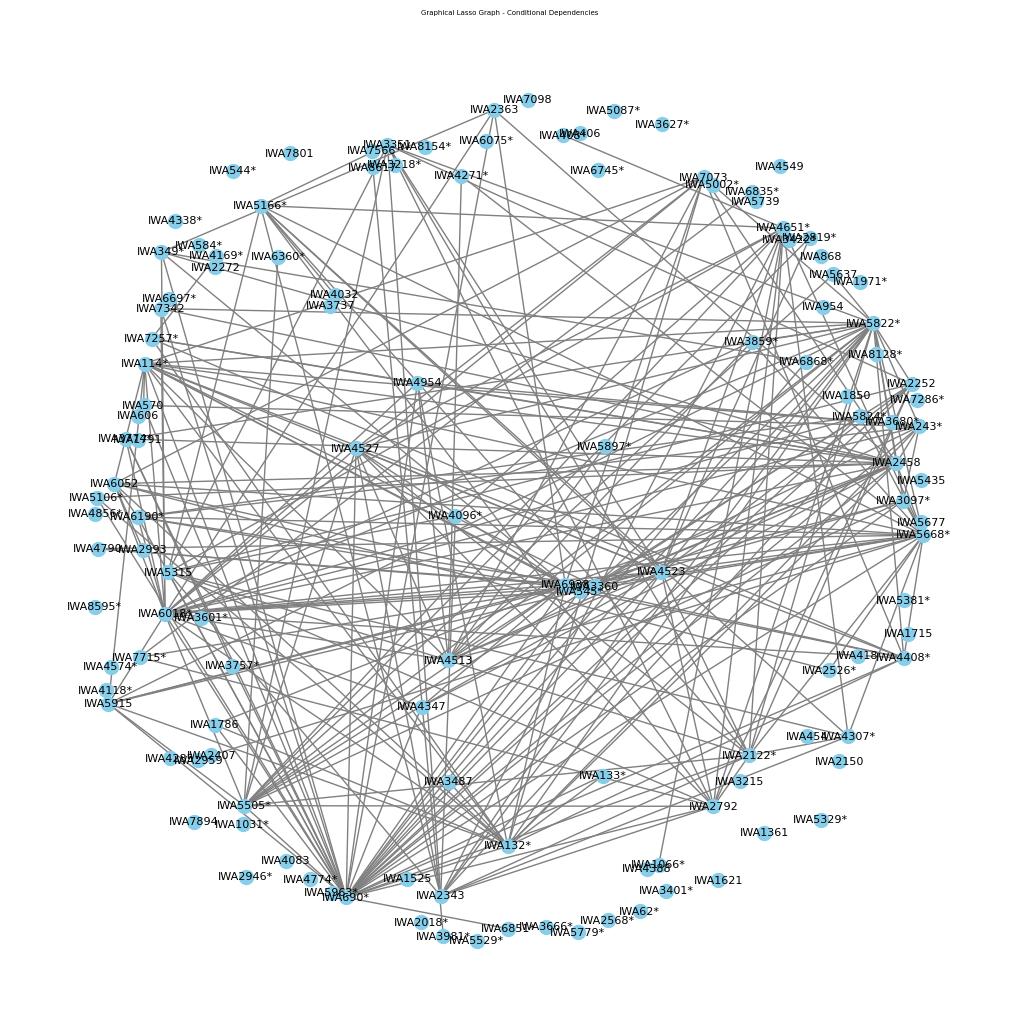

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from(feature_names)

for i in range(precision_matrix.shape[0]):
    for j in range(i + 1, precision_matrix.shape[1]):
        if precision_matrix[i, j] != 0:
            G.add_edge(feature_names[i], feature_names[j], weight=precision_matrix[i, j])

# Visualize the graph
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=100, node_color='skyblue', font_size=8, edge_color='gray')
plt.title('Graphical Lasso Graph - Conditional Dependencies', size=5)
plt.show()

In [17]:
from torch_geometric.utils import add_self_loops

feature_to_idx = {feat: idx for idx, feat in enumerate(feature_names)}

edge_index = torch.tensor(
    [[feature_to_idx[u], feature_to_idx[v]] for u, v in G.edges()],
    dtype=torch.long
).t().contiguous()

print(edge_index.shape)

torch.Size([2, 257])


In [18]:
edge_features = []
for u, v in G.edges():
    edge_features.append(precision_matrix[feature_to_idx[u], feature_to_idx[v]])
edge_features = torch.tensor(edge_features, dtype=torch.float).unsqueeze(1)

print(edge_features.shape)

torch.Size([257, 1])


### Graph Attention Network (GAT)

In [19]:
from torch_geometric.nn.conv import GATv2Conv, GCNConv
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn.pool import global_add_pool, global_mean_pool

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, edge_dim, heads=8, dropout=0.1):
        super(GAT, self).__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=heads, edge_dim=edge_dim, dropout=dropout)
        self.conv2 = GATv2Conv(hidden_channels * heads, hidden_channels, heads=1, edge_dim=edge_dim, concat=False, dropout=dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.skip_proj1 = nn.Linear(in_channels, hidden_channels * heads)
        self.skip_proj2 = nn.Linear(hidden_channels * heads, hidden_channels)
        self.lin = nn.Linear(hidden_channels, out_channels)

        self.reset_parameters()

    def reset_parameters(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, edge_index, edge_attr, batch):
        x_skip1 = self.skip_proj1(x)
        x_gat = self.conv1(x, edge_index, edge_attr=edge_attr)
        x_gat = F.relu(x_gat + x_skip1)
        x_gat = self.dropout1(x_gat)

        x_skip2 = self.skip_proj2(x_gat)
        x_gat = self.conv2(x_gat, edge_index, edge_attr=edge_attr)
        x_gat = F.relu(x_gat + x_skip2)
        x_gat = self.dropout2(x_gat)

        out = global_add_pool(x_gat, batch)
        out = self.lin(out)
        return out

In [20]:
SEED = 42
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [21]:
BATCH_SIZE = 64
LEARNING_RATE = 6e-3
EPOCHS = 200
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [22]:
def build_data_list(X_in, y_in, edge_index):
    data_list = []
    snp_features =  df['Unnamed: 1'][1:].values.astype(float)
    for i in range(X_in.shape[0]):
        x = torch.tensor(np.vstack([X_in[i], snp_features]).T, dtype=torch.float)
        y = y_in[i]
        data = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_features,
            y=y
        )
        data_list.append(data)
    return data_list

In [23]:
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

train_data_list = build_data_list(X_train, y_train, edge_index)
val_data_list = build_data_list(X_val, y_val, edge_index)
test_data_list = build_data_list(X_test, y_test, edge_index)

train_loader = DataLoader(train_data_list, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data_list, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data_list, batch_size=BATCH_SIZE, shuffle=False)

In [24]:
in_channels = train_data_list[0].x.shape[1]
out_channels = train_data_list[0].y.shape[0]
edge_dim = edge_features.shape[1]

hidden_channels = 128

In [25]:
model = GAT(in_channels=in_channels, hidden_channels=hidden_channels, out_channels=out_channels, edge_dim=edge_dim).to(DEVICE)

In [26]:
criterion = nn.MSELoss()

In [27]:
def train(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = criterion(out.view(-1), data.y.view(-1).float())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in val_loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.edge_attr, data.batch)
            loss = criterion(out.view(-1), data.y.view(-1).float())
            total_loss += loss.item() * data.num_graphs
    return total_loss / len(val_loader.dataset)

def test(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.edge_attr, data.batch)
            loss = criterion(out.view(-1), data.y.view(-1).float())
            total_loss += loss.item() * data.num_graphs
    return total_loss / len(test_loader.dataset)

In [28]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [30]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

In [31]:
gat_train_losses = []
gat_val_losses = []

for epoch in range(1, EPOCHS+1):
    train_loss = train(model, train_loader, optimizer, criterion, DEVICE)
    val_loss = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)
    if epoch % 10 == 0 or epoch == 1 or epoch == EPOCHS:
      print(f'Epoch: {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
    gat_train_losses.append(train_loss)
    gat_val_losses.append(val_loss)

Epoch: 001 | Train Loss: 270266.0447 | Val Loss: 447.3212
Epoch: 010 | Train Loss: 282.6777 | Val Loss: 266.8114
Epoch: 020 | Train Loss: 210.3957 | Val Loss: 256.3242
Epoch: 030 | Train Loss: 274.0503 | Val Loss: 252.3149
Epoch: 040 | Train Loss: 172.1794 | Val Loss: 137.1581
Epoch: 050 | Train Loss: 155.4440 | Val Loss: 144.5980
Epoch: 060 | Train Loss: 145.4205 | Val Loss: 130.4194
Epoch: 070 | Train Loss: 186.4335 | Val Loss: 124.2469
Epoch: 080 | Train Loss: 132.0895 | Val Loss: 207.8887
Epoch: 090 | Train Loss: 123.1840 | Val Loss: 138.9061
Epoch: 100 | Train Loss: 125.9244 | Val Loss: 154.8909
Epoch: 110 | Train Loss: 120.1964 | Val Loss: 139.2070
Epoch: 120 | Train Loss: 118.5634 | Val Loss: 152.0691
Epoch: 130 | Train Loss: 119.1546 | Val Loss: 146.9212
Epoch: 140 | Train Loss: 119.3226 | Val Loss: 147.2825
Epoch: 150 | Train Loss: 117.0173 | Val Loss: 149.5807
Epoch: 160 | Train Loss: 122.5461 | Val Loss: 148.8986
Epoch: 170 | Train Loss: 121.0556 | Val Loss: 147.3012
Epoch: 

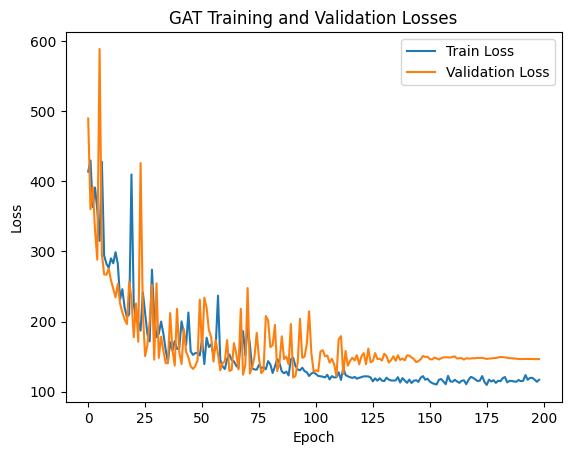

In [32]:
import matplotlib.pyplot as plt

# ignore outlier
plt.plot(gat_train_losses[1:], label='Train Loss')
plt.plot(gat_val_losses[1:], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('GAT Training and Validation Losses')
plt.show()

In [33]:
test_loss = test(model, test_loader, criterion, DEVICE)
print(f'Test Loss: {test_loss:.4f}')

Test Loss: 141.8497


In [34]:
# check MSE, MAE test data
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
with torch.no_grad():
    model.eval()
    y_pred = []
    y_true = []
    for data in test_loader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        y_pred.append(out.cpu().numpy())
y_pred = np.concatenate(y_pred, axis=0)
y_true = y_test
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
print(f'MSE: {mse:.4f} | MAE: {mae:.4f}')

MSE: 141.8497 | MAE: 7.1959


### Baseline MLP

In [35]:
SEED = 42
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [36]:
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 200
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [37]:
class MLP(nn.Module):
    def __init__(self, input_channels, hidden_channels, output_channels, dropout=0.1):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_channels, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, output_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        return x

In [39]:
control_model = MLP(input_channels=X_train.shape[1], hidden_channels=128, output_channels=y_train.shape[1]).to(DEVICE)
optimizer = torch.optim.Adam(control_model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

In [40]:
def train_mlp(model, Xs, ys, optimizer, criterion, device):
    control_model.train()
    train_loss = 0
    Xs = Xs.to(device)
    ys = ys.to(device)
    for i in range(len(Xs)):
        x = Xs[i].unsqueeze(0)
        y = ys[i].unsqueeze(0)
        optimizer.zero_grad()
        out = control_model(x)
        loss = criterion(out.view(-1), y.view(-1).float())
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
    train_loss = train_loss / len(Xs)
    return train_loss

def val_mlp(model, Xs, ys, criterion, device):
    control_model.eval()
    val_loss = 0
    Xs = Xs.to(device)
    ys = ys.to(device)
    with torch.no_grad():
        for i in range(len(Xs)):
            x = Xs[i].unsqueeze(0)
            y = ys[i].unsqueeze(0)
            out = control_model(x)
            loss = criterion(out.view(-1), y.view(-1).float())
            val_loss += loss.item()
    val_loss = val_loss / len(Xs)
    return val_loss

In [42]:
mlp_train_losses = []
mlp_val_losses = []
for epoch in range(1, EPOCHS+1):
    train_loss = train_mlp(control_model, X_train, y_train, optimizer, criterion, DEVICE)
    val_loss = val_mlp(control_model, X_val, y_val, criterion, DEVICE)
    scheduler.step(val_loss)
    if epoch % 10 == 0 or epoch == 1 or epoch == EPOCHS:
      print(f'Epoch: {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
    mlp_train_losses.append(train_loss)
    mlp_val_losses.append(val_loss)

Epoch: 001 | Train Loss: 676.8752 | Val Loss: 185.4407
Epoch: 010 | Train Loss: 56.2311 | Val Loss: 140.0438
Epoch: 020 | Train Loss: 27.0032 | Val Loss: 140.4590
Epoch: 030 | Train Loss: 17.0512 | Val Loss: 149.7912
Epoch: 040 | Train Loss: 12.4615 | Val Loss: 148.6969
Epoch: 050 | Train Loss: 11.3776 | Val Loss: 151.0172
Epoch: 060 | Train Loss: 10.0326 | Val Loss: 150.0022
Epoch: 070 | Train Loss: 9.0672 | Val Loss: 151.3843
Epoch: 080 | Train Loss: 9.3607 | Val Loss: 150.7126
Epoch: 090 | Train Loss: 9.2223 | Val Loss: 150.9516
Epoch: 100 | Train Loss: 8.9806 | Val Loss: 150.8666
Epoch: 110 | Train Loss: 8.3760 | Val Loss: 150.9521
Epoch: 120 | Train Loss: 8.2671 | Val Loss: 150.9876
Epoch: 130 | Train Loss: 9.3845 | Val Loss: 150.9897
Epoch: 140 | Train Loss: 8.9967 | Val Loss: 151.0241
Epoch: 150 | Train Loss: 8.9865 | Val Loss: 151.0110
Epoch: 160 | Train Loss: 9.2098 | Val Loss: 151.0175
Epoch: 170 | Train Loss: 9.1553 | Val Loss: 151.0192
Epoch: 180 | Train Loss: 8.4249 | Val 

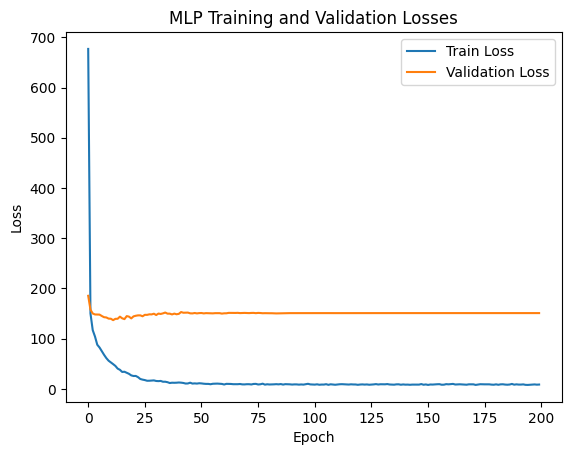

In [43]:
plt.plot(mlp_train_losses, label='Train Loss')
plt.plot(mlp_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('MLP Training and Validation Losses')
plt.show()

In [44]:
control_model.eval()
test_loss = 0
with torch.no_grad():
    for i in range(len(X_test)):
        x = X_test[i].unsqueeze(0).to(DEVICE)
        y = y_test[i].unsqueeze(0).to(DEVICE)
        out = control_model(x)
        loss = criterion(out.view(-1), y.view(-1).float())
        test_loss += loss.item()
test_loss = test_loss / len(X_test)
print(f'Test Loss: {test_loss:.4f}')

Test Loss: 162.0328


In [45]:
with torch.no_grad():
    control_model.eval()
    y_pred = []
    y_true = []
    for i in range(len(X_test)):
        x = X_test[i].unsqueeze(0).to(DEVICE)
        y = y_test[i].unsqueeze(0).to(DEVICE)
        out = control_model(x)
        y_pred.append(out.cpu().numpy())
y_pred = np.concatenate(y_pred, axis=0)
y_true = y_test
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
print(f'MSE: {mse:.4f} | MAE: {mae:.4f}')

MSE: 162.0328 | MAE: 7.3936
